# Phase 3B — AST Fine-Tuning with Focal Loss

**Project:** RobustLungAI — Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers.

## Objective

Investigate focal loss as an alternative to cross-entropy for four-class respiratory sound classification using the pretrained Audio Spectrogram Transformer (AST).

## Experimental design

This experiment reuses the project’s patient-level train, validation and test splits, pretrained AST checkpoint, cached waveforms and training pipeline. Focal loss uses a focusing parameter of \(\gamma=2.0\) and class-specific weights to address class imbalance.

## Evaluation

The best checkpoint is selected using validation ICBHI score and early stopping. Final performance is reported using sensitivity, specificity, ICBHI score, four-class classification reports and confusion matrices.

## Reproducibility

The experiment uses the project’s internal 70/15/15 patient-level split. Comparisons with the cross-entropy baseline are meaningful only when data splits, preprocessing, model configuration and evaluation metrics are consistent.

## Outputs

* Best validation-selected AST checkpoint.
* Training and validation curves.
* Validation and test metrics.
* Results CSV for subsequent experiment comparisons.


In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torch.nn.functional as F

from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110 # Matplotlib figures render at 110 DPI.

## **1. Config**

Identical to `03_ast_finetuning_ce`'s config, except:
- `WAVEFORM_CACHE_DIR` now points at the **mounted CE notebook's** cache, not a fresh local one
- One new hyperparameter: `FOCAL_GAMMA`
- Results save to a separate `results_phase3b.csv`, merged with the others at write-up time

In [2]:
# =========================
# Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# =========================
# Paths
# =========================

# Phase 1 notebook output -- for splits/train.csv, val.csv, test.csv
PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"


CE_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce"
)
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"

CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = Path("/kaggle/working/results_phase3b.csv")


# =========================
# Labels
# =========================
LABELS = ["normal", "crackle", "wheeze", "both"]  


# =========================
# Audio preprocessing constants 
# =========================
TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0


# =========================
# AST model config
# =========================
AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"


# =========================
# Training config 
# =========================
BATCH_SIZE = 8
NUM_WORKERS = 2
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
MAX_EPOCHS = 15
EARLY_STOP_PATIENCE = 4
GRAD_CLIP_NORM = 1.0

# Focal Loss specific
FOCAL_GAMMA = 2.0   # standard default (Lin et al., 2017); higher = more
                

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert DEVICE.type == "cuda" # "Enable the GPU accelerator for this notebook before continuing.

Device: cuda


## **2. Load Phase 1 splits**

In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df   = pd.read_csv(SPLIT_DIR / "val.csv")
test_df  = pd.read_csv(SPLIT_DIR / "test.csv")

required_cols = {"audio_path", "start", "end", "label"}
missing = required_cols - set(train_df.columns)
assert not missing, f"Missing expected columns: {missing}"

print(train_df.shape, val_df.shape, test_df.shape)

(4580, 14) (1133, 14) (1185, 14)


## **3. Resolve Existing Waveform Cache Paths**

Each manifest row is mapped to its previously generated waveform cache file using the recording filename and respiratory-cycle start and end times.

This step only resolves existing files. It does not regenerate missing waveforms. If any expected cache file is missing, execution stops with an error so that the cache can be checked deliberately.


In [ ]:
from pathlib import Path

def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    # Recreate the exact filename used during Phase 1
    cycle_id = f"{Path(row['audio_path']).stem}_{float(row['start'])}_{float(row['end'])}"
    
    waveform_path = cache_dir / f"{cycle_id}.npy"

    # We only look for the existing waveform.
    # We do NOT regenerate it.
    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


# Create waveform_path column for all splits
for name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["waveform_path"] = [
        resolve_waveform_path(row)
        for _, row in df.iterrows()
    ]

    print(f"{name}: {len(df)} waveform paths created")

print("\nAll waveform paths resolved successfully.")

## **4. AST Feature Extraction and DataLoaders**

The dataset loads cached waveforms on demand, passes each waveform through the pretrained AST feature extractor and returns the model input tensor with its class label.

The DataLoaders batch examples for training, validation and testing. A batch-shape check verifies that the inputs match the expected AST representation before training begins.

No new waveform cache is generated in this step.


In [7]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

class ASTLungSoundDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.label2idx = {l: i for i, l in enumerate(label_list)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])
        features = self.fe(waveform, sampling_rate=TARGET_SR, return_tensors="pt")
        x = features["input_values"].squeeze(0)
        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y


train_ds = ASTLungSoundDataset(train_df, feature_extractor)
val_ds   = ASTLungSoundDataset(val_df, feature_extractor)
test_ds  = ASTLungSoundDataset(test_df, feature_extractor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print("Batch input shape:", xb.shape)   # expect (BATCH_SIZE, 1024, 128)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Batch input shape: torch.Size([8, 1024, 128])


## **5. Load the pretrained model (identical to CE notebook)**

In [8]:
id2label = {i: l for i, l in enumerate(LABELS)}
label2id = {l: i for i, l in enumerate(LABELS)}

model = ASTForAudioClassification.from_pretrained(
    AST_CHECKPOINT,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Total parameters: 86,191,876


## 6. Focal Loss

**Focal Loss** extends Cross-Entropy (CE) by reducing the contribution of easy, confidently classified samples and focusing more on difficult examples.

The multi-class formulation is:

$$
FL = -\alpha_t(1-p_t)^\gamma \log(p_t)
$$

where:

- **$p_t$** = predicted probability of the true class
- **$\gamma$** = focusing parameter controlling the emphasis on hard examples
- **$\alpha_t$** = class-specific weight used to handle class imbalance

When **$p_t \rightarrow 1$**, the focal factor **$(1-p_t)^\gamma \rightarrow 0$**, so easy examples contribute less to the loss. When **$p_t$** is small, the focal factor remains large, providing a stronger learning signal for difficult examples.

### Implementation Note

**$p_t$ must be computed from unweighted Cross-Entropy:**

$$
p_t = e^{-CE}
$$

Class weights are applied **after** computing $p_t$:

$$
\text{Loss} = \alpha_t(1-p_t)^\gamma CE
$$

This keeps **class rebalancing** ($\alpha_t$) separate from **hard-example focusing** ($(1-p_t)^\gamma$).

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha        # per-class weights, applied separately from p_t
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # unweighted CE -- this is what correctly recovers p_t via exp(-ce_loss)
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        p_t = torch.exp(-ce_loss)                      # true predicted prob of the true class
        focal_term = (1 - p_t) ** self.gamma

        loss = focal_term * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]               # gather per-example class weight
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


class_counts = train_df["label"].value_counts().reindex(LABELS).fillna(0)
class_weights = (1.0 / class_counts).values
class_weights = class_weights / class_weights.sum() * len(LABELS)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(dict(zip(LABELS, class_weights.cpu().numpy().round(3))))

criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = GradScaler("cuda")

{'normal': np.float32(0.331), 'crackle': np.float32(0.616), 'wheeze': np.float32(1.049), 'both': np.float32(2.003)}


## **7. Shared evaluation metric — ICBHI Score**

In [10]:
def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])
    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / normal_mask.sum()
    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / abnormal_mask.sum()
    score = (sensitivity + specificity) / 2
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": score}


idx2label = {i: l for i, l in enumerate(LABELS)}

def evaluate_and_report(y_true, y_pred, model_name):
    scores = icbhi_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"Sensitivity: {scores['sensitivity']*100:.2f}%")
    print(f"Specificity: {scores['specificity']*100:.2f}%")
    print(f"ICBHI Score:  {scores['icbhi_score']*100:.2f}%\n")
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return scores


results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)

## **8. Training Loop and Checkpoint Selection**

The training loop uses focal loss with mixed-precision training, gradient clipping and a learning-rate scheduler.

After each epoch, validation performance is measured using the ICBHI score. The best validation checkpoint is saved, and early stopping is applied when the validation score does not improve for the configured patience period.

The scheduler advances only when the gradient scaler has not skipped the optimizer update because of overflow. This keeps the learning-rate schedule aligned with successful optimizer steps under automatic mixed precision.

The loss function is the main experimental change relative to the cross-entropy baseline; other training settings should remain consistent for a controlled comparison.


In [11]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if is_train:
                optimizer.zero_grad()

            with autocast("cuda"):
                logits = model(input_values=xb).logits
                loss = criterion(logits, yb)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

                scale_before = scaler.get_scale()
                scaler.step(optimizer)
                scaler.update()
                scale_after = scaler.get_scale()


                if scale_after >= scale_before:
                    scheduler.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            all_true.extend(idx2label[i] for i in yb.cpu().numpy())
            all_pred.extend(idx2label[i] for i in preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    scores = icbhi_score(all_true, all_pred)
    return avg_loss, scores


history = {"train_loss": [], "val_loss": [], "val_icbhi_score": []}
best_val_score = -1
epochs_without_improvement = 0
best_checkpoint_path = CHECKPOINT_DIR / "ast_focal_best.pt"

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, _ = run_epoch(model, train_loader, criterion, optimizer, scheduler, scaler)
    val_loss, val_scores = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_icbhi_score"].append(val_scores["icbhi_score"])

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_ICBHI_score={val_scores['icbhi_score']*100:.2f}%")

    if val_scores["icbhi_score"] > best_val_score:
        best_val_score = val_scores["icbhi_score"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  -> new best (saved to {best_checkpoint_path.name})")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 01 | train_loss=0.3649 | val_loss=0.3056 | val_ICBHI_score=70.49%
  -> new best (saved to ast_focal_best.pt)
Epoch 02 | train_loss=0.2408 | val_loss=0.3267 | val_ICBHI_score=70.19%
Epoch 03 | train_loss=0.1492 | val_loss=0.3901 | val_ICBHI_score=69.12%
Epoch 04 | train_loss=0.0760 | val_loss=0.4996 | val_ICBHI_score=63.80%
Epoch 05 | train_loss=0.0278 | val_loss=0.6458 | val_ICBHI_score=64.27%
Early stopping at epoch 5


### **Training curves**

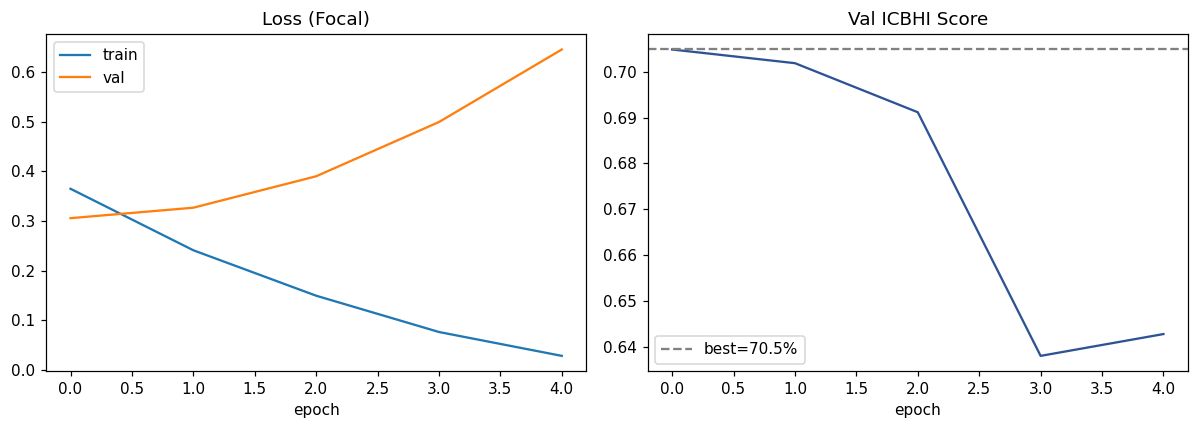

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss (Focal)")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["val_icbhi_score"], color="#2E5395")
axes[1].axhline(best_val_score, linestyle="--", color="gray", label=f"best={best_val_score*100:.1f}%")
axes[1].set_title("Val ICBHI Score")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

## **9. Evaluate best checkpoint (val), then test set once**

--- AST + Focal Loss (val, best checkpoint) ---
Sensitivity: 61.49%
Specificity: 79.49%
ICBHI Score:  70.49%

              precision    recall  f1-score   support

      normal       0.74      0.79      0.77       663
     crackle       0.56      0.51      0.53       347
      wheeze       0.44      0.68      0.53        66
        both       0.50      0.04      0.07        57

    accuracy                           0.66      1133
   macro avg       0.56      0.51      0.47      1133
weighted avg       0.66      0.66      0.65      1133



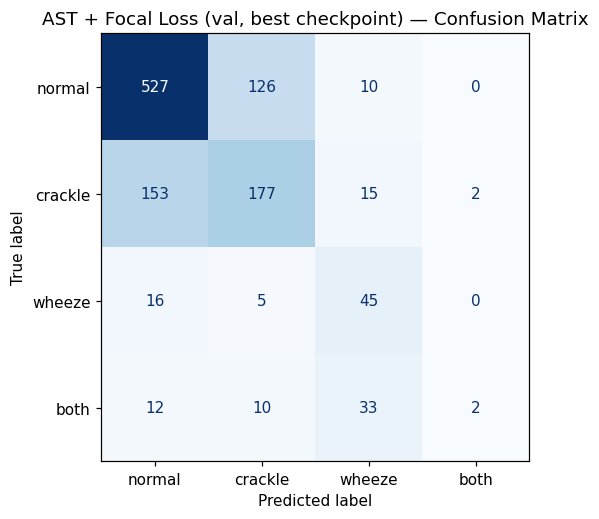

In [13]:
model.load_state_dict(torch.load(best_checkpoint_path))
model.eval()

def predict_all(loader):
    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)
    return all_true, all_pred


val_true, val_pred = predict_all(val_loader)
focal_val_scores = evaluate_and_report(val_true, val_pred, "AST + Focal Loss (val, best checkpoint)")
log_result("AST + Focal Loss", "val", focal_val_scores, notes=f"gamma={FOCAL_GAMMA}")

--- AST + Focal Loss (TEST) ---
Sensitivity: 48.32%
Specificity: 83.22%
ICBHI Score:  65.77%

              precision    recall  f1-score   support

      normal       0.71      0.83      0.76       709
     crackle       0.51      0.23      0.32       298
      wheeze       0.31      0.54      0.40       104
        both       0.27      0.14      0.18        74

    accuracy                           0.61      1185
   macro avg       0.45      0.43      0.42      1185
weighted avg       0.60      0.61      0.58      1185



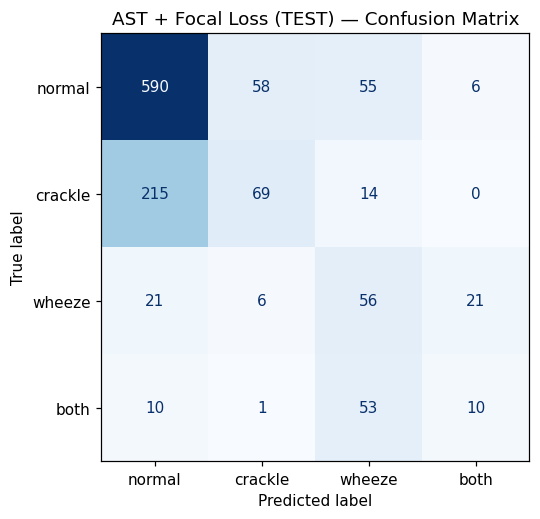

In [14]:
# --- TEST set ---
test_true, test_pred = predict_all(test_loader)
focal_test_scores = evaluate_and_report(test_true, test_pred, "AST + Focal Loss (TEST)")
log_result("AST + Focal Loss", "test", focal_test_scores, notes=f"gamma={FOCAL_GAMMA}")

## **10. Focal-Loss Results**

The following table contains the validation and test metrics recorded by this focal-loss experiment. The results are exported to `results_phase3b.csv`.

The cross-entropy baseline is maintained separately. A combined comparison table should be assembled from the verified result files of both experiments, using the same evaluation protocol and metric definitions.


In [15]:
results_df = pd.DataFrame(results_log)
results_df["sensitivity"] = (results_df["sensitivity"] * 100).round(2)
results_df["specificity"] = (results_df["specificity"] * 100).round(2)
results_df["icbhi_score"] = (results_df["icbhi_score"] * 100).round(2)

display_cols = ["model", "split", "sensitivity", "specificity", "icbhi_score", "notes"]
results_df[display_cols].to_csv(RESULTS_CSV, index=False)
results_df[display_cols]


,model,split,sensitivity,specificity,icbhi_score,notes
0,AST + Focal Loss,val,61.49,79.49,70.49,gamma=2.0
1,AST + Focal Loss,test,48.32,83.22,65.77,gamma=2.0


## 11. Phase 3B Summary

This experiment fine-tunes AST using class-weighted focal loss with \(\gamma=2.0\), reusing the project’s existing waveform cache and patient-level data splits.

### Completed work

* Reused cached waveform files without regenerating them.
* Fine-tuned the four-class AST classifier using focal loss.
* Selected the checkpoint using validation ICBHI score.
* Recorded training curves, validation metrics and test metrics.
* Exported the experiment results to `results_phase3b.csv`.

### Interpretation

This experiment provides a focal-loss comparison point for the cross-entropy baseline. Differences in results should be interpreted in the context of class imbalance, validation-based checkpoint selection and the shared evaluation protocol.

### Limitations

The internal patient-level 70/15/15 split is not interchangeable with the official ICBHI split used by some published studies. Results are research measurements and do not establish clinical diagnostic performance.

### Next experiment

Phase 3C investigates supervised contrastive learning. Its results should be evaluated with the same attention to split consistency, preprocessing and test-set isolation.
